# Airbnb Price Prediction
#### By Damiru Vidunitha Wanniarachchi (S4137361)

### How to Run:
1. Install required libraries
2. Place `train_data.csv` and `test_data.csv` in `dataset` folder in the same directory
3. Run all cells sequencially

## 1.0 Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

## 2.0 Dataset

Loading the training and test datasets provided on Canvas. The training dataset includes the target variable `price` whereas the test dataset does not.

## 2.1 Load Dataset

In [3]:
# dataframes
df_tr = pd.read_csv('dataset/train_data.csv')
df_te = pd.read_csv('dataset/test_data.csv')

## 2.2 Exploratory Data Analysis

### Understanding the data

In [4]:
df_tr.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [5]:
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               8586 non-null

In [6]:
df_tr.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


The dataset contains 8586 listing and 16 features. As it is indicated above, the dataset has non-null values for all the entries for all the columns, so **no missing data** in present.

Some numerical features such as `Price`, `minimum_nights`indicate varying ranges and distributions.
For example, `Price` has a *mean* of ~139.77 whereas it ranges from a minimum of 0 to 3000 showing a **right-skewed distribution**. This suggests that there's a small number of high-priced house listings that may influence the overall distribution.

### Feature Types

In [7]:
# binary features for binary encoding
ft_bin = ['host_is_superhost', 'instant_bookable']

# categorical features for one-hot encoding
ft_cat = ['city', 'country', 'room_type']

# Numerical features (excluding price)
ft_num = ['latitude', 'longitude', 'accommodates', 'bathrooms', 
                'bedrooms', 'beds', 'minimum_nights',
                'number_of_reviews', 'review_scores_rating', 
                'calculated_host_listings_count']

### Distribution of Price

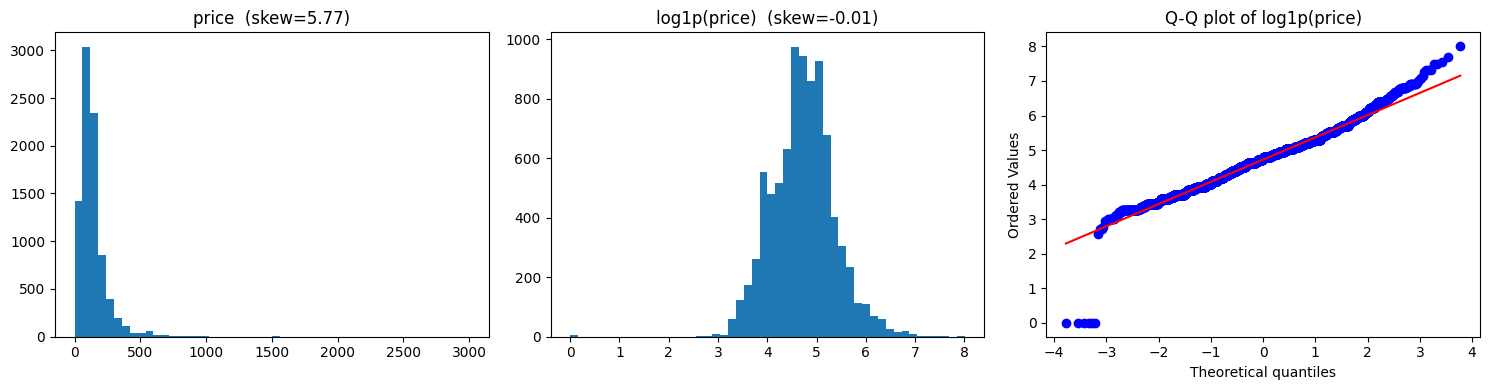

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# raw price
axes[0].hist(df_tr['price'], bins=50)
axes[0].set_title(f'price  (skew={df_tr["price"].skew():.2f})')

# log price
price_log = np.log1p(df_tr['price']) # log1p: safer handling zeros
axes[1].hist(price_log, bins=50)
axes[1].set_title(f'log1p(price)  (skew={price_log.skew():.2f})')

# q-q plot
stats.probplot(price_log, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot of log1p(price)')

plt.tight_layout()

As we deducted before, the *raw price distribution* is **strongly right-skewed (skweness = $5.77$)** where the vast majority of the prices lie within the **$0-500$** range indicating that most listings are relatively affordable with a small number of high-priced *outliers.* This *violates homoscedasticity* of linear regression (**heteroscedasticity**) where error variances across data are unequal, making the high-priced listings *disproportionately influencial*. However, after applying *log1p* the skewness has been **reduced to $-0.01$** producing a more symmetric distribution suitable for linear models.

The *Q-Q plot* showcases the *quantiles of the transformed data vs a normal distribution* incidcating that the transformed data follows a normal distribution with *minor deviation* on the tail consistent with the few extreme-priced listings remaining in the data, further *strengthening the transformation*.

### Missing values

In [9]:
print(df_tr.isnull().sum()[df_tr.isnull().sum() > 0])

Series([], dtype: int64)


The above check for *null values(**NaNs**)* revealed that there're no missing values of the training dataset.

However, further investigation for *$0* listings (`price`) should be conducted as these outliers could provide *false signals* to the model.

In [10]:
print(f"Number of $0 listings: {(df_tr['price'] <= 0).sum()}")

Number of $0 listings: 6


These $\$0$ listings should be handled accordingly during **Data Preprocessing**.

### Numerical Features vs. Log(Price)

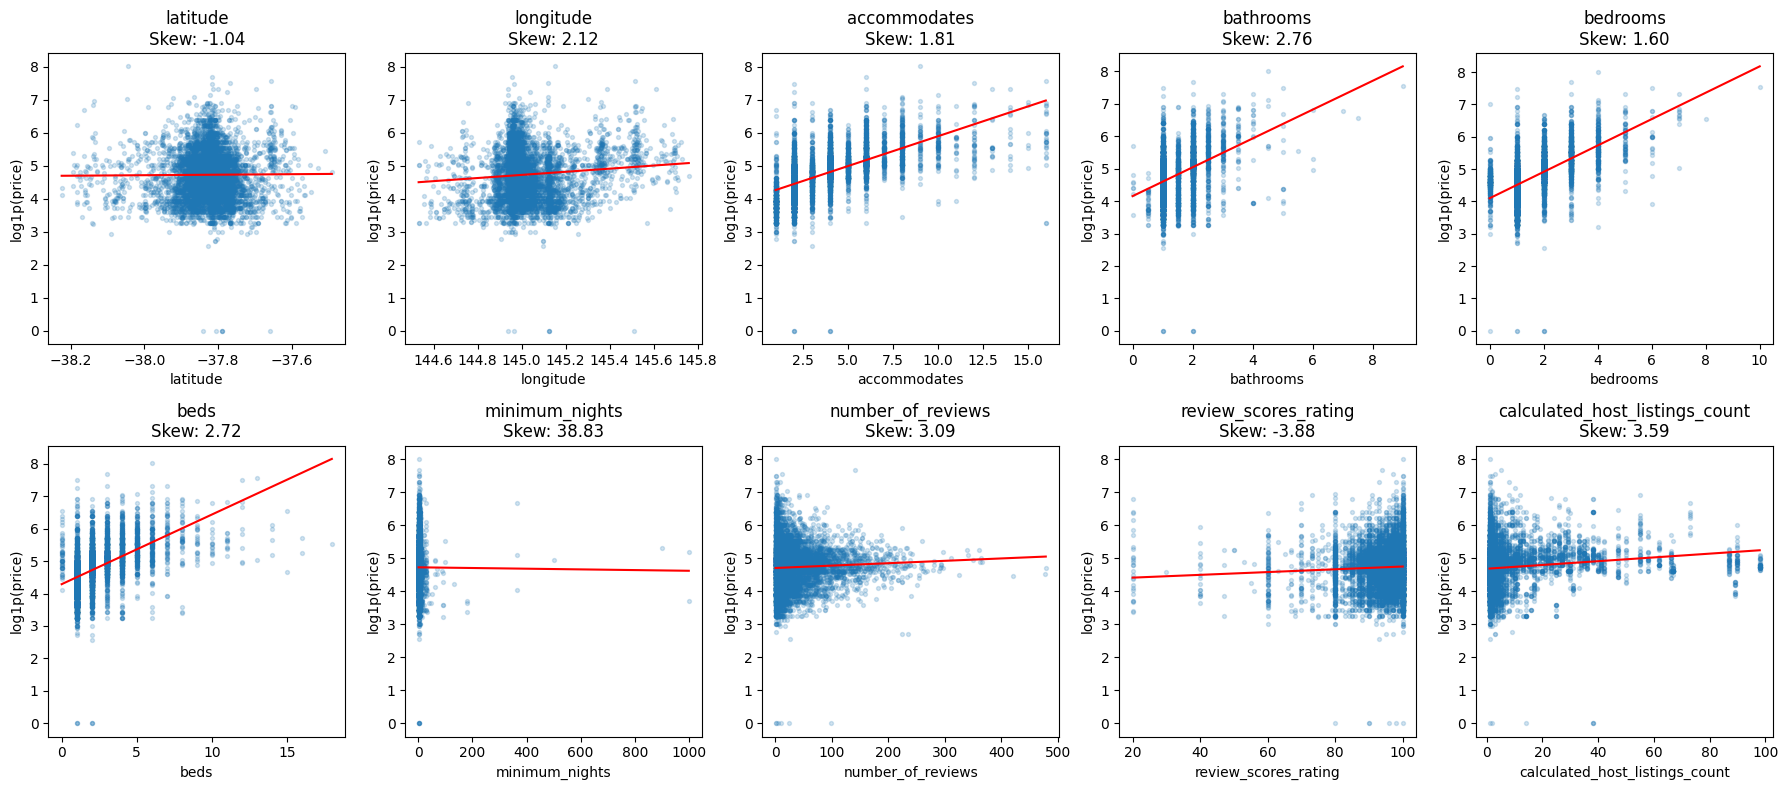

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, feat in zip(axes.flatten(), ft_num):
    ax.scatter(df_tr[feat], np.log1p(df_tr['price']), alpha=0.2, s=8)
    ax.set_title(f'{feat}\nSkew: {df_tr[feat].skew():.2f}')
    ax.set_xlabel(feat)
    ax.set_ylabel('log1p(price)')
    
    # regression line to see linear trend
    m, b = np.polyfit(df_tr[feat].fillna(df_tr[feat].median()), np.log1p(df_tr['price']), 1)
    x_line = np.linspace(df_tr[feat].min(), df_tr[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'r-', linewidth=1.5)
    
plt.tight_layout()

Features such as `accommodates`, `bathrooms`, `bedrooms`, and `beds` show *positive linear trends* with *log1p(price)*, indicating that larger, better-equipped listings tend to have higher prices. They also showcase some *skewness* to the right.

Other numerical features showcase weaker relationships:

- `latitude` and `longitude` are mostly flat, with data clustered to the middle of the ranges which are *melbourne inner suburbs*.

- `minimum_nights` is *heavily right-skewed*(skew=$38.83$), with most listings are near zero, showing small linear trend.
- `number_of_reviews`(skew=$3.09$) and `calculated_host_listings_count`(skew=$3.59$) also show *right-skewed distribution* eventhough not as heavy with *linear trends*.
- `review_scores_rating` shows a *left-skewed distribution*(skew=$-3.88$) indicating most listings got higher review ratings which limits discriminative power.

Overall, the *log transformation* stablizes *residual variance* across prices (*homoscedasticity*) and enhances existing *linear trends*, making data more *suitable* for the models. In short, `log1p(price)` proves to be a better target for *regression models*. 

### Categorical Features vs. Log(Price)

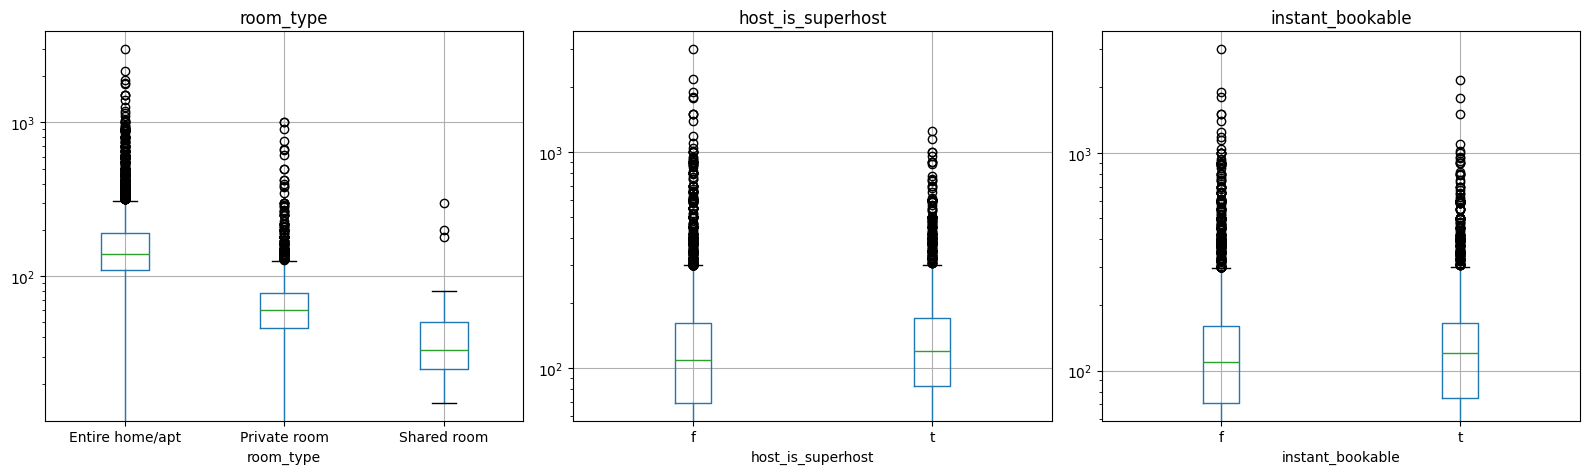

In [12]:
# load training data again to access original data
df_tr_original = pd.read_csv('dataset/train_data.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['room_type', 'host_is_superhost', 'instant_bookable']):
    df_tr_original.boxplot(column='price', by=feat, ax=ax)
    ax.set_yscale('log')  # log scale on y so you can actually see the boxes
    ax.set_title(feat)
plt.suptitle('')
plt.tight_layout()

`room_type` feature shows strong grouping across all three types, with differing medians. This feature is *one-hot encoded* and is expected to have *high coeficient magnitude* in all models. Most of the *outliers (high-priced listings)* are very concentrated within the 'Entire home/apt' and 'Private room' agreeing to the nature of luxury rentals.

`host_is_superhost` however, shows minimal differetiation of prices with median prices being nearly identical across both types. This suggests that `host_is_superhost` does not command a higher price in the dataset. Therefore, this feature may contribute *less* to model performance. As for *outlier density and range* of this feature, moderate difference is present, but not significant enough to support that `host_is_superhost` feature drive the price of listings.

`instant_bookable` too shows minimal differentiation of prices with almost identical medians. The *outlier density* of the types are nearly identical suggesting that this feature does not have considerable influence on prices of listings as well.

### Correlation Heatmap

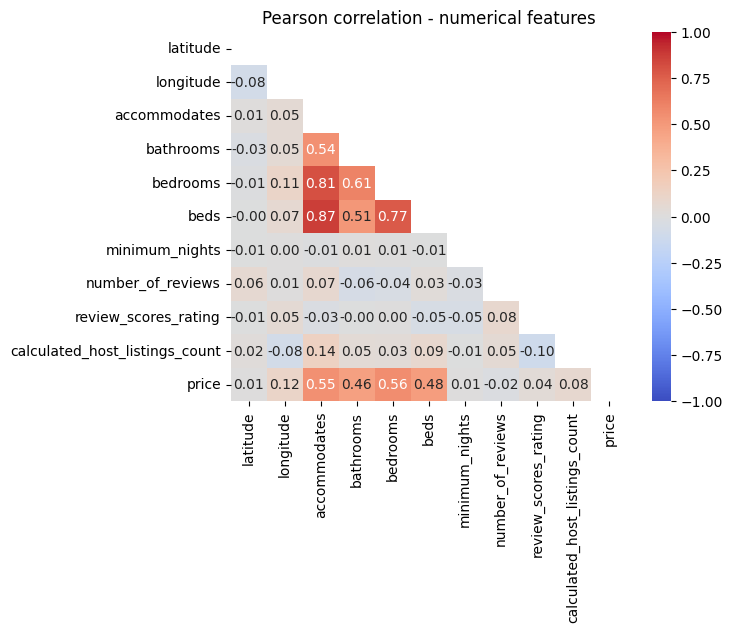

In [13]:
corr = df_tr[ft_num + ['price']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Pearson correlation - numerical features')
plt.show()

The pearson correlation heatmap above, shows that features related to the *physical capacity of Airbnbs* such as `accommodates` ($0.55$), `bedrooms` ($0.56$) indicate the strongest positive linear relationship with *price*.

However, it is also clear that significant **multicolinearity** is present between `beds`/`accommodates` ($0.87$), `bedrooms`/`accommodates` ($0.81$), and `beds`/`bedrooms` ($0.77$). In *Ordinary Least Squares (ols)*, multicolinearity inflates *coefficient varience* where even small changes in data could produce large changes in individual coefficients. This problem directly motivates **Ridge Regression** where large coefficients are penalised which would stabalise the model.

Interestingly, *marketing and behavioural metrics* such as `number_of_reviews`, `reviews_scores_rating`, and `minimum_nights` showcase weaker, negligible correlation with *price*. Since, Pearson correlation only captures linear correlations, these features may contribute indirectly as a combination with other features. To automatically discard features that adds no signal at all, **Lasso Regression** could be applied where the model would shrink the *non-informative feature coefficients* to zero (implicit *feature selection*).

## 2.3 Data Preprocessing

### Data Cleaning

The previous EDA identified a few $\$0$ listings ($n=6$). To ensure that the model stays focused, these rows would be removed from the *training dataframe*.

In [14]:
# create mask for valid prices
df_tr = df_tr[df_tr['price'] > 0].copy()

# verify there're no $0 listings
print(f"Number of $0 listings: {(df_tr['price'] <= 0).sum()}")

Number of $0 listings: 0


### Transformation Pipeline

In order to centralise out data preprocessing logic, maintain consistency, and handle different data types, a `ColumnTransformer` is implemented.

**Log1p**: The logarithmic transformation is applied to *eligible right-skewed numerical features* (`minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`) to ensure stable variance and to normalise the distribution. The other features (`accommodates`, `bathrooms`, `bedrooms`, `beds`) were deemed *ineligible* as they are *descrete counts* and keeping as-is provides better interpretability.

**Yeo-Johnson**: Used for the left-skewed feature `review_scores_rating` via Scikit-Learns's `PowerTransformer` as standard Log transformation is ineffective in handling extreme negative skewness.

**One-Hot Encoding**: Used for categorical features (`city`, `country`, `room_type`) since machine learning models cannot work directly with strings. `drop='first'` is used to avoid the *Dummy variable trap* (Multicolinearity).

**StandardScalar**: Applied to all numerical and binary features leaving out the categorical features since they are one-hot encoded. This step is essential for *Regularisation*, where the regularisation-penalty is scale-sensitve. Unscaled features would be penalised proportionaly to their values instead of the contribution making the regularisation *unfair*.

In [39]:
# Feature groups
ft_bin = ['host_is_superhost', 'instant_bookable']
ft_cat = ['city', 'country', 'room_type']
ft_log = ['minimum_nights', 'number_of_reviews', 
          'calculated_host_listings_count']
ft_yeo = ['review_scores_rating']
ft_num = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'longitude', 'latitude']

# binary encoding
map_bool = {'t': 1, 'f': 0, True: 1, False: 0}
for col in ft_bin:
    df_tr[col] = df_tr[col].map(map_bool)
    df_te[col] = df_te[col].map(map_bool)

# pipelines for groups needing transform + scale
log_pipeline = Pipeline([
    ('log',   FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler())
])

yeo_pipeline = Pipeline([
    ('yeo',   PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('bin', StandardScaler(),                                              ft_bin),
    ('log', log_pipeline,                                                  ft_log),
    ('yeo', yeo_pipeline,                                                  ft_yeo),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                          sparse_output=False),                            ft_cat),
    ('num', StandardScaler(),                                              ft_num)
])

### Data Splitting

To maintain experimental integrity, the data is split before applying the transformations. This approach also prevents **Data Leakage**. Only `X_train_raw` is used to fit the `preprocessor` for the *mean* and *standard deviation* to be derived from the training data. The same parameters are then used for transforming the validation and test sets.

In [40]:
X = df_tr.drop(columns=['price'])
y = np.log1p(df_tr['price'])
X_test_raw = df_te.copy()

# random state set to 7, for reproduability
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=7
)

# only use training data for parameter derivation
X_train = preprocessor.fit_transform(X_train_raw)

X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

print(f"X shapes: Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"y shapes: Train: {y_train.shape}, Val: {y_val.shape}")

X shapes: Train: (6864, 43), Val: (1716, 43), Test: (8585, 43)
y shapes: Train: (6864,), Val: (1716,)


## 3.0 Model Development

### 3.1 Evaluation Function

In [52]:
warnings.filterwarnings('ignore')

def evaluate_model(name, model, X_tr, X_v, y_tr, y_v):
    """
    Evaluates a fitted model on both train and validation sets.
    Reports metrics on log scale (model fit) and original dollar scale (for interpretability).
    """
    train_pred = model.predict(X_tr)
    val_pred   = model.predict(X_v)

    # log scale metrics
    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    val_rmse   = np.sqrt(mean_squared_error(y_v, val_pred))
    val_mae    = mean_absolute_error(y_v, val_pred)
    val_r2     = r2_score(y_v, val_pred)

    # original dollar scale
    val_pred_orig = np.expm1(val_pred)
    y_v_orig      = np.expm1(y_v)
    val_rmse_orig = np.sqrt(mean_squared_error(y_v_orig, val_pred_orig))
    val_mae_orig  = mean_absolute_error(y_v_orig, val_pred_orig)

    print(f"\n{'-'*50}")
    print(f"{name}")
    print(f"{'-'*50}")
    print(f"Train RMSE (log):  {train_rmse:.4f}")
    print(f"Val   RMSE (log):  {val_rmse:.4f}  {'possible overfit' if val_rmse - train_rmse > 0.1 else ''}")
    print(f"Val   MAE  (log):  {val_mae:.4f}")
    print(f"Val   R²:          {val_r2:.4f}")
    print(f"Val   RMSE ($):    {val_rmse_orig:.2f}")
    print(f"Val   MAE  ($):    {val_mae_orig:.2f}")

    return {
        'name': name, 'train_rmse': train_rmse, 'val_rmse': val_rmse,
        'val_mae': val_mae, 'val_r2': val_r2,
        'val_rmse_orig': val_rmse_orig, 'val_mae_orig': val_mae_orig
    }

# all model results (final compariison)
results = []

## 3.2 *Model 1*: Baseline Linear Regression (OLS)

In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)

results.append(evaluate_model('Baseline Linear Regression', lr, 
                               X_train, X_val, y_train, y_val))


--------------------------------------------------
Baseline Linear Regression
--------------------------------------------------
Train RMSE (log):  0.3705
Val   RMSE (log):  0.3724  
Val   MAE  (log):  0.2726
Val   R²:          0.6318
Val   RMSE ($):    85.30
Val   MAE  ($):    40.46


The *Ordinary Least Squares (Baseline Linear Regression)* minimises the residual sum of squares. This model finds the optimal coefficients via the normal equation:
$$\hat{\theta}=(X^\top X)^{-1}X^\top y$$
Since there's no regularisation or special focus on relevent features involved, this model serves as the *Baseline*. Therefore, *Lasso* and *Ridge* would be evaluated against this.

Relevent to this dataset, OLS has two vulnerabilities. One is *multicolinearity* which inflates the coefficient variance and was found during the Exploratory Data Analysis existing between `accommodates`, `bedrooms`, and `beds`. The other is the unnecessary inclusion of features regardless of their contribution and relevence which would introduce noise and dull the linear predictor.

## 3.3 *Model 2*: Ridge Regression

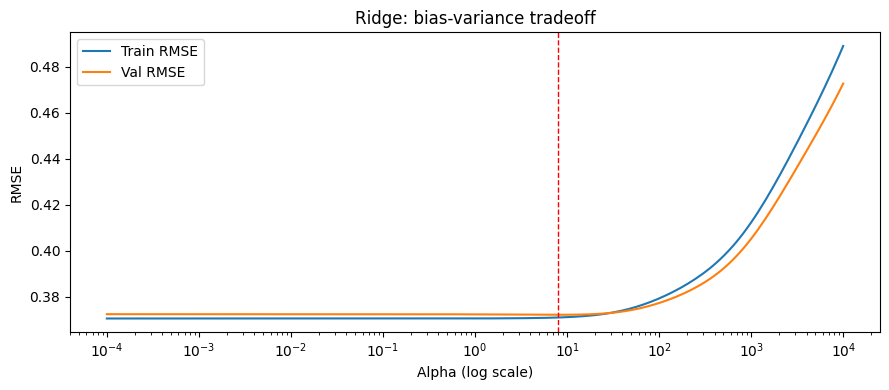

Best Ridge alpha: 8.0264

--------------------------------------------------
Ridge Regression
--------------------------------------------------
Train RMSE (log):  0.3709
Val   RMSE (log):  0.3721  
Val   MAE  (log):  0.2728
Val   R²:          0.6323
Val   RMSE ($):    85.23
Val   MAE  ($):    40.44


In [54]:
# Hyperparameter sweep on log scale
alphas = np.logspace(-4, 4, 200)
ridge_train_rmse, ridge_val_rmse = [], []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, ridge.predict(X_train))))
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val, ridge.predict(X_val))))

# bias-variance tradeoff
plt.figure(figsize=(9, 4))
plt.semilogx(alphas, ridge_train_rmse, label='Train RMSE', linewidth=1.5)
plt.semilogx(alphas, ridge_val_rmse,   label='Val RMSE',   linewidth=1.5)
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge: bias-variance tradeoff')
plt.legend()
plt.axvline(alphas[np.argmin(ridge_val_rmse)], color='red', 
            linestyle='--', linewidth=1, label=f'Best alpha')
plt.tight_layout()
plt.show()

# fit final Ridge with best alpha
best_alpha_ridge = alphas[np.argmin(ridge_val_rmse)]
print(f"Best Ridge alpha: {best_alpha_ridge:.4f}")

ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train, y_train)
results.append(evaluate_model('Ridge Regression', ridge_best,
                               X_train, X_val, y_train, y_val))

Ridge Regression is *L2* penalty added to the OLS objective.
$$L_{total}(w)=L_{original/OLS}(w) + \lambda\sum_iw_i^2$$
(where: $\lambda$ is the regularisation strength (alpha though denoted as lambda))

After *increasing* the total loss with respect to the weights, the same weights are penalised (shrunk) proportionally towards zero during gradient descent. This directly addresses *multicolinearity* by reducing the coefficient variences and provices stable, and reliable predictions.

*gradient descent weight update:$$w_i \leftarrow w_i-\eta\bigg(\frac{\partial L}{\partial w_i}+\lambda w_i\bigg)$$

As $\lambda\rightarrow0$, the model starts acting as an OLS. As shown above, at a lower $\lambda$ `Train` and `Val` RMSE diverge (variance-dominated). But as $\lambda\rightarrow\infty$ (grows higher) both RMSE increase together (bias-dominated). The optimal $\lambda$ is the value that minimises RMSE on validation data which is $\lambda=8.0264$. The $R^2$ of $0.6323$ indicates the Ridge model explains a significant amount of the variance in the data, with still a considerable amount sits unaccounted for.

Ridge Regression here is heavily motivated due to the *multicolinearity* between some features identified during EDA which the *OLS model was unable to address effectively*.

## 3.4 *Model 3*: Lasso Regression

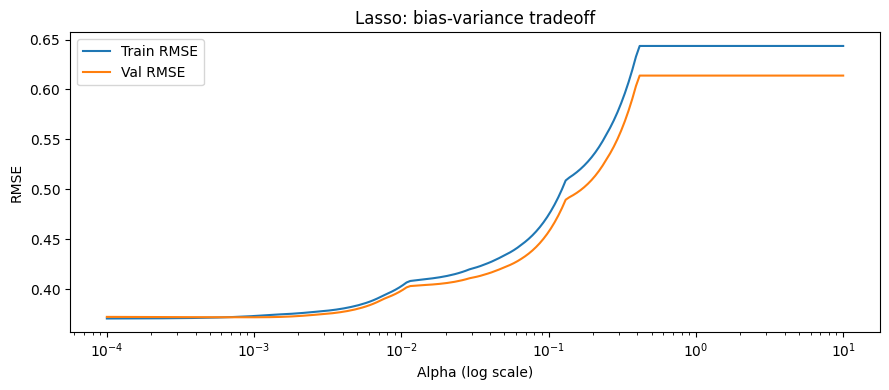

Best Lasso alpha: 0.0010

--------------------------------------------------
Lasso Regression
--------------------------------------------------
Train RMSE (log):  0.3729
Val   RMSE (log):  0.3718  
Val   MAE  (log):  0.2726
Val   R²:          0.6330
Val   RMSE ($):    85.30
Val   MAE  ($):    40.44

Features retained: 29 / 43
Features zeroed out: 14

Top 10 by magnitude:
cat__room_type_Shared room    -0.983789
cat__room_type_Private room   -0.584959
cat__city_Yarra Ranges         0.348710
cat__city_Melbourne            0.249188
cat__city_Yarra                0.225757
cat__city_Port Phillip         0.194128
cat__city_Stonnington          0.173031
num__bedrooms                  0.156990
cat__city_Bayside              0.123200
cat__city_Brimbank            -0.118354
dtype: float64


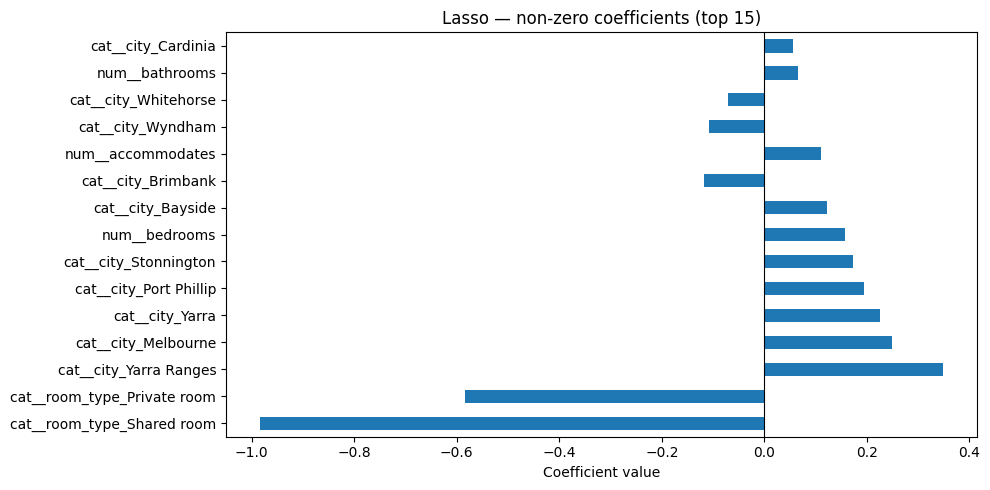

In [55]:
alphas_lasso = np.logspace(-4, 1, 200)
lasso_train_rmse, lasso_val_rmse = [], []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train, lasso.predict(X_train))))
    lasso_val_rmse.append(np.sqrt(mean_squared_error(y_val, lasso.predict(X_val))))

# plot
plt.figure(figsize=(9, 4))
plt.semilogx(alphas_lasso, lasso_train_rmse, label='Train RMSE', linewidth=1.5)
plt.semilogx(alphas_lasso, lasso_val_rmse,   label='Val RMSE',   linewidth=1.5)
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso: bias-variance tradeoff')
plt.legend()
plt.tight_layout()
plt.show()

best_alpha_lasso = alphas_lasso[np.argmin(lasso_val_rmse)]
print(f"Best Lasso alpha: {best_alpha_lasso:.4f}")

lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train, y_train)
results.append(evaluate_model('Lasso Regression', lasso_best,
                               X_train, X_val, y_train, y_val))

# feature selection analysis
feature_names = preprocessor.get_feature_names_out()
lasso_coefs   = pd.Series(lasso_best.coef_, index=feature_names)

nonzero = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
zeroed  = lasso_coefs[lasso_coefs == 0]

print(f"\nFeatures retained: {len(nonzero)} / {len(lasso_coefs)}")
print(f"Features zeroed out: {len(zeroed)}")
print(f"\nTop 10 by magnitude:\n{nonzero.head(10)}")

# plot non-zero coefficients
plt.figure(figsize=(10, 5))
nonzero.head(15).plot(kind='barh')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value')
plt.title('Lasso — non-zero coefficients (top 15)')
plt.tight_layout()
plt.show()

Lasso Regression adds the *L1 penalty* to the OLS objective.
$$L_{total}(w)=L(w)+\lambda\sum_{i=1}^n|w_i|$$
(where: $\lambda$ is the regularisation strength)

Unlike Ridge, Lasso could produce exact zeros, completely stopping the error signal flowing back through the gradients if a feature was to contribute insufficiently.
$$\frac d{dw}|w| =
\begin{cases} 
+1 & \text{if } w > 0 \\[2mm]
-1 & \text{if } w < 0 \\[2mm]
0\ \text{(in practice)} & \text{if } w = 0
\end{cases}$$

This quality of Lasso Regression makes it an implicit *feature selection method* while keeping its regressive qualities.

As the above analysis indicate, Lasso has dropped $14$ of its $43$ features which were deemed insufficient in contribution and relevence, notably `cat_room_type_Shared_room`, and `cat_room_type_Private_room`. The model identified `room_type` as a primary driver of price variance as deducted during the EDA. Since `Entire_home/apt` was used as the reference category (dropped during encoding), these coefficients makes it clear that prices for booking a full property is a massive increase compared to private/shared rooms.

Lasso also serves as the more *interpretable* approch for hosts using the model as a pricing guide as there are fewer features compared to other models, and less likely to overfit on new, unseen data.

The Lasso Hyperparameter tuning reveals the transition from an optimal fit to a highly biased state. Minimised RMSE at the optimal alpha ($\lambda=0.001$) is $0.3718$ with very small divergence between training and validation error. After alpha crosses the $0.1$ mark, RMSE seems to have a sharp inflection as the L1 penalty becomes too restrictive. The $R^2=0.633$ ensures that the Lasso model captures majority of the variance in pricing signal.

## 3.5 *Cross-Validation* on All Models

In [56]:
# K-fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=best_alpha_ridge),
    'Lasso':             Lasso(alpha=best_alpha_lasso, max_iter=10000)
}

print("5-Fold Cross-Validation Results (RMSE on log scale)")
print("-"*50)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    mean, std = -scores.mean(), scores.std()
    cv_results[name] = {'mean': mean, 'std': std}
    print(f"{name:25s}  RMSE: {mean:.4f} ± {std:.4f}")

5-Fold Cross-Validation Results (RMSE on log scale)
--------------------------------------------------
Linear Regression          RMSE: 0.3737 ± 0.0099
Ridge                      RMSE: 0.3739 ± 0.0097
Lasso                      RMSE: 0.3750 ± 0.0092


Cross-validation (with $k=5$) provides a better and a more reliable performance estimate than a single data split as each fold uses a different $20%$ for validation. The $\pm$ standard deviation measures the model's stability under unseen data. The results above indicate that any of the models' performance is *not heavily sensitive* to which data it trains on as they range $\pm\ 0.0092-0.0099$. This ensures the models are reliable for real-world deployment.

## 3.6 Residual Analysis

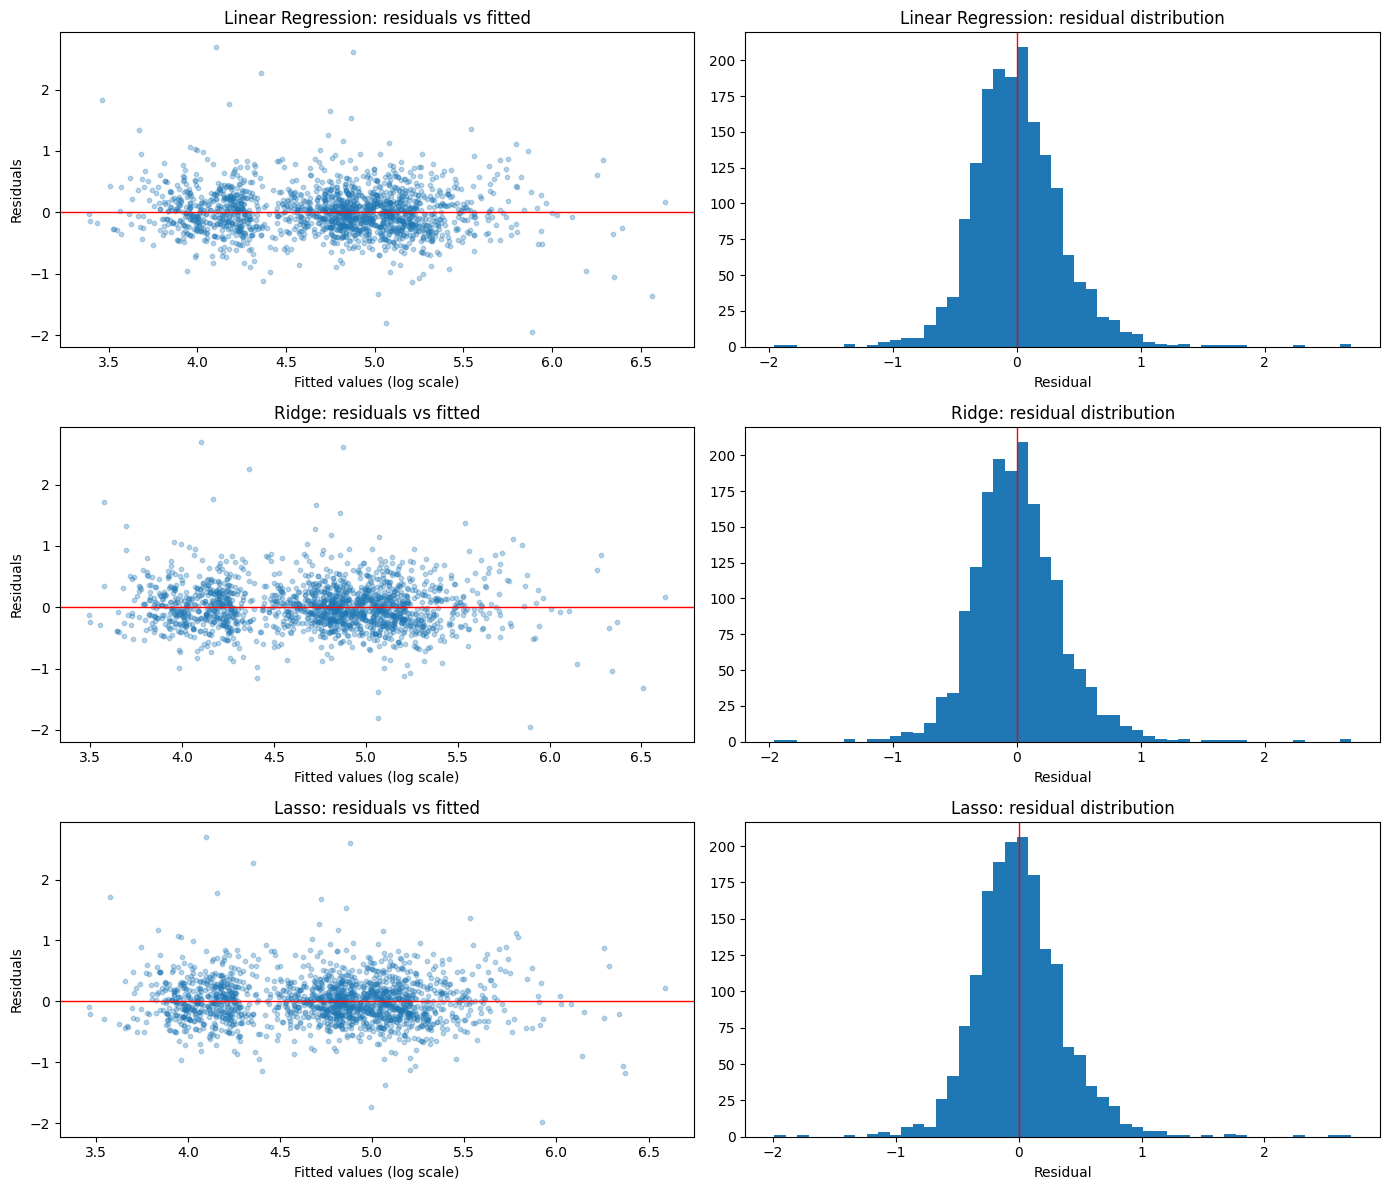

In [59]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

fitted_models = [
    ('Linear Regression', lr),
    ('Ridge',             ridge_best),
    ('Lasso',             lasso_best)
]

for i, (name, model) in enumerate(fitted_models):
    val_pred  = model.predict(X_val)
    residuals = y_val - val_pred

    # Residuals vs fitted
    axes[i, 0].scatter(val_pred, residuals, alpha=0.3, s=10)
    axes[i, 0].axhline(0, color='red', linewidth=1)
    axes[i, 0].set_xlabel('Fitted values (log scale)')
    axes[i, 0].set_ylabel('Residuals')
    axes[i, 0].set_title(f'{name}: residuals vs fitted')

    # Residual distribution
    axes[i, 1].hist(residuals, bins=50)
    axes[i, 1].set_xlabel('Residual')
    axes[i, 1].set_title(f'{name}: residual distribution')
    axes[i, 1].axvline(0, color='red', linewidth=1)

plt.tight_layout()
plt.show()

The Residual Analysis evaluates the validity of the linear regression assumptions. All three models' 'residuals vs fitted' indicate *homoscedasticity*, with errors distributed randomly around the *zero-line* regardless of the fitted values (predicted price). Moreover, the residual distribution histograms showcase very desirable normal distribution patterns demonstrating the effectiveness of the *log-transformation of the target variable `price`* as well as the use of *parametric linear models* for this task.

Even though a few number of outliers do exist, the overall analysis suggests that the model captures the general market trend.

## 4.0 Final Comparison of Models & Justification


Final Model Comparison
----------------------------------------------------------------------------------------------------
                            train_rmse  val_rmse  val_mae  val_r2  val_rmse_orig  val_mae_orig
name                                                                                          
Baseline Linear Regression      0.3705    0.3724   0.2726  0.6318        85.3014       40.4572
Ridge Regression                0.3709    0.3721   0.2728  0.6323        85.2305       40.4418
Lasso Regression                0.3729    0.3718   0.2726  0.6330        85.2980       40.4396


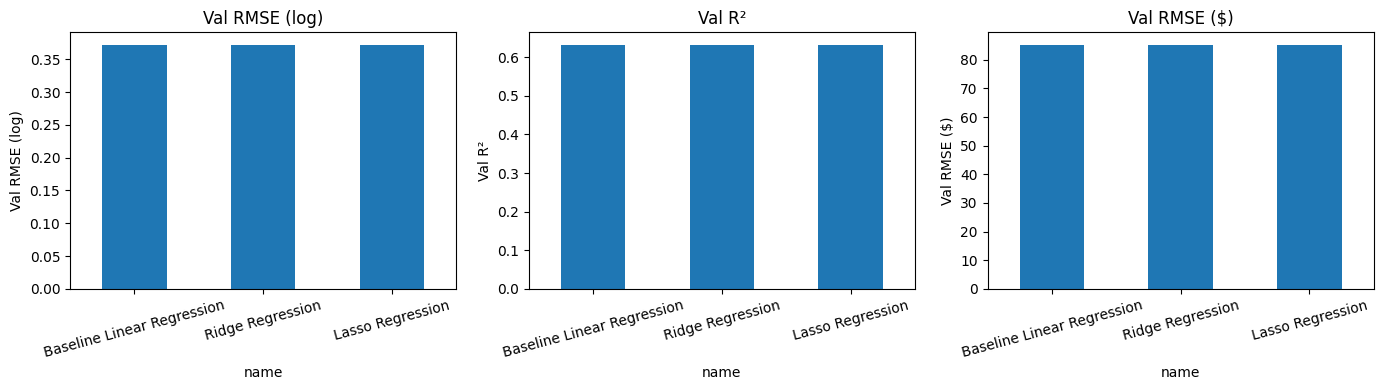

In [61]:
results_df = pd.DataFrame(results).set_index('name')

print("\nFinal Model Comparison")
print("-"*100)
print(results_df[['train_rmse', 'val_rmse', 'val_mae', 
                   'val_r2', 'val_rmse_orig', 'val_mae_orig']].round(4).to_string())

# visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [('val_rmse', 'Val RMSE (log)'), 
           ('val_r2',   'Val R²'), 
           ('val_rmse_orig', 'Val RMSE ($)')]

for ax, (metric, label) in zip(axes, metrics):
    results_df[metric].plot(kind='bar', ax=ax, rot=15)
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### Performance

All three models performed within a very tight range with an RMSE difference of $<0.001$. This suggests that the relationship between the *target value* (`log price`) and the features (`beds`, `accommodates`, etc) is well captured by linear models and that the 'signal' in the data is consistent throughout different regularisation techniques. However, it should be noted that the *Lasso Regression Model* proved to be the **best performing** option as it achieved the lowest RMSE (`val_rmse`=$0.3718$) across all three models.

### Sparsity

Despite the similarities of the scores, the *Lasso Regression Model* has achieved a great level of sparsity over the other two models. The Lasso Model achieved the lowest RMSE while performing **implicit feature selection**, shrinking 14 non-informative features to zero effectively. This ensures that the Lasso Model is much more versatile and stable when it comes to the melbourne property market data.

### Regularisation Impact

It is clear that regularisation (penalties on coefficient magnitude) helped both the *regularised models* Lasso and Ridge to achieve better performance than the Baseline model (OLS) even in marginal amounts. This prevented the model over-relying on categorical features such as specific suburbs which are significantly richer than the rest, ultimately leading to an *overfit*.

## 4.1 Final Model Justification

### Selected Model: Lasso Regression ($\lambda\text{ reffered to as alpha}=0.001$)
The Lasso Regression Model was chosen for the final deployment. The justification is as follows:
- **Predictive Accuracy**: Produced the highest $R^2$ value and the lowest RMSE.
- **Robustness**: As illustrated in the *bias-variance tradeoff* the chosen alpha lies at the optimal point of generalisation ($\lambda=0.001$).
- **Validity**: The *Residual Analysis* further verified that the Lasso model satisfies all linear assumptions made, producing unbiased predictions.

In [63]:
# the best alpha from your manual loop
best_alpha_lasso = alphas_lasso[np.argmin(lasso_val_rmse)]

print(f"Best Lasso alpha: {best_alpha_lasso:.4f}")

# define and fit 'lasso_best' using that specific alpha
# set max_iter=12000 to ensure the model converges fully
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=12000)
lasso_best.fit(X_train, y_train)

Best Lasso alpha: 0.0010


Lasso(alpha=0.0009547716114208056, max_iter=12000)

In [67]:
df_te.columns

Index(['host_is_superhost', 'city', 'country', 'latitude', 'longitude',
       'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'instant_bookable', 'calculated_host_listings_count'],
      dtype='str')

In [69]:
# preprocess the test features
X_test_final = preprocessor.transform(df_te)

# generate predictions (in log-space)
log_predictions = lasso_best.predict(X_test_final)

# inverse transform to actual dollars
# np.expm1 is the inverse of np.log1p
final_prices = np.expm1(log_predictions)

# create submission DataFrame
submission = pd.DataFrame({
    'id': df_te.index, 
    'price': final_prices
})

# round up to 2 decimal points
submission['price'] = submission['price']

# export to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' generated successfully!!!")
print(f"Sample of predicted prices:\n{submission['price'].head()}")

Submission file 'submission.csv' generated successfully!!!
Sample of predicted prices:
0     43.720012
1    127.367845
2     58.917649
3     43.505971
4     69.831278
Name: price, dtype: float64
